In [0]:
import torch

print(torch.__version__)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-3ebf2153-7aee-4335-9ba7-daad6add2dbc/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


2.12.0+cu130


In [0]:
%pip install einops tqdm scipy scikit-learn matplotlib --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

# ETSformer aplicado a consumo eléctrico

## Objetivo

Usaremos el archivo `LD2011_2014.txt` para entrenar un modelo ETSformer que prediga consumo eléctrico futuro.

El dataset contiene mediciones cada 15 minutos de múltiples clientes eléctricos.

Empezaremos con un caso simple:

- seleccionaremos un cliente,
- usaremos su consumo pasado,
- predeciremos su consumo futuro.

Formalmente:

\[
X_{t-L:t} \rightarrow X_{t:t+H}
\]

Donde:

- \(L\) es la cantidad de datos históricos usados.
- \(H\) es la cantidad de pasos futuros a predecir.

En este primer experimento:

| Parámetro | Valor | Interpretación |
|---|---:|---|
| `seq_len` | 96 | últimas 24 horas |
| `pred_len` | 24 | próximas 6 horas |
| frecuencia | 15 minutos | frecuencia original del dataset |

%md
# 1. Clonar ETSformer

ETSformer es un modelo publicado por Salesforce Research.

Usaremos su repositorio oficial porque ya contiene:

- arquitectura del modelo,
- código de entrenamiento,
- carga de datos,
- evaluación,
- métricas.

En Databricks usaremos `/tmp/ETSformer` como carpeta de trabajo.

In [0]:
%sh

cd /tmp

if [ ! -d "ETSformer" ]; then
  git clone https://github.com/salesforce/ETSformer.git
fi

cd ETSformer
ls

Cloning into 'ETSformer'...


CODE_OF_CONDUCT.md
CODEOWNERS
data_provider
dataset
exp
LICENSE.txt
models
pics
README.md
requirements.txt
run.py
scripts
SECURITY.md
utils


In [0]:
repo_dir = "/tmp/ETSformer"

print("Repositorio ETSformer:", repo_dir)

Repositorio ETSformer: /tmp/ETSformer


# 2. Indicar la ubicación del archivo

El archivo `LD2011_2014.txt` ya está cargado en Unity Catalog Volumes.

La ruta correcta es:

`/Volumes/workspace/etsformer/raw_files/LD2011_2014.txt`

Esta ruta es la que usaremos para leer el archivo con Pandas.

In [0]:
raw_file_path = "/Volumes/workspace/etsformer/raw_files/LD2011_2014.txt"

print("Archivo de datos:", raw_file_path)

Archivo de datos: /Volumes/workspace/etsformer/raw_files/LD2011_2014.txt


In [0]:
import pandas as pd

test_df = pd.read_csv(
    raw_file_path,
    sep=";",
    decimal=",",
    nrows=5
)

display(test_df)

Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,MT_011,MT_012,MT_013,MT_014,MT_015,MT_016,MT_017,MT_018,MT_019,MT_020,MT_021,MT_022,MT_023,MT_024,MT_025,MT_026,MT_027,MT_028,MT_029,MT_030,MT_031,MT_032,MT_033,MT_034,MT_035,MT_036,MT_037,MT_038,MT_039,MT_040,MT_041,MT_042,MT_043,MT_044,MT_045,MT_046,MT_047,MT_048,MT_049,MT_050,MT_051,MT_052,MT_053,MT_054,MT_055,MT_056,MT_057,MT_058,MT_059,MT_060,MT_061,MT_062,MT_063,MT_064,MT_065,MT_066,MT_067,MT_068,MT_069,MT_070,MT_071,MT_072,MT_073,MT_074,MT_075,MT_076,MT_077,MT_078,MT_079,MT_080,MT_081,MT_082,MT_083,MT_084,MT_085,MT_086,MT_087,MT_088,MT_089,MT_090,MT_091,MT_092,MT_093,MT_094,MT_095,MT_096,MT_097,MT_098,MT_099,MT_100,MT_101,MT_102,MT_103,MT_104,MT_105,MT_106,MT_107,MT_108,MT_109,MT_110,MT_111,MT_112,MT_113,MT_114,MT_115,MT_116,MT_117,MT_118,MT_119,MT_120,MT_121,MT_122,MT_123,MT_124,MT_125,MT_126,MT_127,MT_128,MT_129,MT_130,MT_131,MT_132,MT_133,MT_134,MT_135,MT_136,MT_137,MT_138,MT_139,MT_140,MT_141,MT_142,MT_143,MT_144,MT_145,MT_146,MT_147,MT_148,MT_149,MT_150,MT_151,MT_152,MT_153,MT_154,MT_155,MT_156,MT_157,MT_158,MT_159,MT_160,MT_161,MT_162,MT_163,MT_164,MT_165,MT_166,MT_167,MT_168,MT_169,MT_170,MT_171,MT_172,MT_173,MT_174,MT_175,MT_176,MT_177,MT_178,MT_179,MT_180,MT_181,MT_182,MT_183,MT_184,MT_185,MT_186,MT_187,MT_188,MT_189,MT_190,MT_191,MT_192,MT_193,MT_194,MT_195,MT_196,MT_197,MT_198,MT_199,MT_200,MT_201,MT_202,MT_203,MT_204,MT_205,MT_206,MT_207,MT_208,MT_209,MT_210,MT_211,MT_212,MT_213,MT_214,MT_215,MT_216,MT_217,MT_218,MT_219,MT_220,MT_221,MT_222,MT_223,MT_224,MT_225,MT_226,MT_227,MT_228,MT_229,MT_230,MT_231,MT_232,MT_233,MT_234,MT_235,MT_236,MT_237,MT_238,MT_239,MT_240,MT_241,MT_242,MT_243,MT_244,MT_245,MT_246,MT_247,MT_248,MT_249,MT_250,MT_251,MT_252,MT_253,MT_254,MT_255,MT_256,MT_257,MT_258,MT_259,MT_260,MT_261,MT_262,MT_263,MT_264,MT_265,MT_266,MT_267,MT_268,MT_269,MT_270,MT_271,MT_272,MT_273,MT_274,MT_275,MT_276,MT_277,MT_278,MT_279,MT_280,MT_281,MT_282,MT_283,MT_284,MT_285,MT_286,MT_287,MT_288,MT_289,MT_290,MT_291,MT_292,MT_293,MT_294,MT_295,MT_296,MT_297,MT_298,MT_299,MT_300,MT_301,MT_302,MT_303,MT_304,MT_305,MT_306,MT_307,MT_308,MT_309,MT_310,MT_311,MT_312,MT_313,MT_314,MT_315,MT_316,MT_317,MT_318,MT_319,MT_320,MT_321,MT_322,MT_323,MT_324,MT_325,MT_326,MT_327,MT_328,MT_329,MT_330,MT_331,MT_332,MT_333,MT_334,MT_335,MT_336,MT_337,MT_338,MT_339,MT_340,MT_341,MT_342,MT_343,MT_344,MT_345,MT_346,MT_347,MT_348,MT_349,MT_350,MT_351,MT_352,MT_353,MT_354,MT_355,MT_356,MT_357,MT_358,MT_359,MT_360,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,71.7703349282297,0,0,0,0,0,0,260.416666666667,45.7217504898759,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68.203368683718,0,38.3422459893048,20.3639846743295,0,1935.18518518519,158.006362672322,1965.43778801843,0,0,838.461538461538,0,50.7562076749436,24.5706051873199,0,137.885196374622,80.7970112079701,0,74.5622119815668,76.7927631578947,41.4825870646766,0,0,0,93.2917316692668,0,39.5888594164456,45.7174556213018,0,0,0,13.4228187919463,22.123745819398,205.83596214511,327.859237536657,920.863309352518,285.607755406413,266.521026761333,1826.27118644068,218.274111675127,12166.6666666667,76.6129032258064,148.867313915858,272.935779816514,428.4140969163,173.089071383449,235.492957746479,319.354838709677,447.761194029851,288.135593220339,110.538373424971,345.578231292517,4235.29411764706,260.9375,472.868217054264,84.0,232.558139534884,603.036876355748,199.59266802444,207.532051282051,1328.90365448505,113.074204946996,680.529300567108,204.301075268817,1278.48101265823,81.7282665278501,444.0,517.333333333333,0,189.121951219512,325.833979829325,228.249744114637,3263.15789473684,582.689335394127,62.219730941704,380.41095890

# 3. Cargar el dataset completo

El archivo tiene estas características:

- separador de columnas: `;`
- decimal europeo: `,`
- primera columna: fecha/hora
- columnas restantes: clientes eléctricos

Cada fila representa una medición cada 15 minutos.

Esto significa:

| Periodo | Registros |
|---|---:|
| 1 hora | 4 |
| 1 día | 96 |
| 1 semana | 672 |

In [0]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    raw_file_path,
    sep=";",
    decimal=",",
    low_memory=False
)

print("Filas y columnas:", df.shape)
display(df.head())

Filas y columnas: (140256, 371)


Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,MT_011,MT_012,MT_013,MT_014,MT_015,MT_016,MT_017,MT_018,MT_019,MT_020,MT_021,MT_022,MT_023,MT_024,MT_025,MT_026,MT_027,MT_028,MT_029,MT_030,MT_031,MT_032,MT_033,MT_034,MT_035,MT_036,MT_037,MT_038,MT_039,MT_040,MT_041,MT_042,MT_043,MT_044,MT_045,MT_046,MT_047,MT_048,MT_049,MT_050,MT_051,MT_052,MT_053,MT_054,MT_055,MT_056,MT_057,MT_058,MT_059,MT_060,MT_061,MT_062,MT_063,MT_064,MT_065,MT_066,MT_067,MT_068,MT_069,MT_070,MT_071,MT_072,MT_073,MT_074,MT_075,MT_076,MT_077,MT_078,MT_079,MT_080,MT_081,MT_082,MT_083,MT_084,MT_085,MT_086,MT_087,MT_088,MT_089,MT_090,MT_091,MT_092,MT_093,MT_094,MT_095,MT_096,MT_097,MT_098,MT_099,MT_100,MT_101,MT_102,MT_103,MT_104,MT_105,MT_106,MT_107,MT_108,MT_109,MT_110,MT_111,MT_112,MT_113,MT_114,MT_115,MT_116,MT_117,MT_118,MT_119,MT_120,MT_121,MT_122,MT_123,MT_124,MT_125,MT_126,MT_127,MT_128,MT_129,MT_130,MT_131,MT_132,MT_133,MT_134,MT_135,MT_136,MT_137,MT_138,MT_139,MT_140,MT_141,MT_142,MT_143,MT_144,MT_145,MT_146,MT_147,MT_148,MT_149,MT_150,MT_151,MT_152,MT_153,MT_154,MT_155,MT_156,MT_157,MT_158,MT_159,MT_160,MT_161,MT_162,MT_163,MT_164,MT_165,MT_166,MT_167,MT_168,MT_169,MT_170,MT_171,MT_172,MT_173,MT_174,MT_175,MT_176,MT_177,MT_178,MT_179,MT_180,MT_181,MT_182,MT_183,MT_184,MT_185,MT_186,MT_187,MT_188,MT_189,MT_190,MT_191,MT_192,MT_193,MT_194,MT_195,MT_196,MT_197,MT_198,MT_199,MT_200,MT_201,MT_202,MT_203,MT_204,MT_205,MT_206,MT_207,MT_208,MT_209,MT_210,MT_211,MT_212,MT_213,MT_214,MT_215,MT_216,MT_217,MT_218,MT_219,MT_220,MT_221,MT_222,MT_223,MT_224,MT_225,MT_226,MT_227,MT_228,MT_229,MT_230,MT_231,MT_232,MT_233,MT_234,MT_235,MT_236,MT_237,MT_238,MT_239,MT_240,MT_241,MT_242,MT_243,MT_244,MT_245,MT_246,MT_247,MT_248,MT_249,MT_250,MT_251,MT_252,MT_253,MT_254,MT_255,MT_256,MT_257,MT_258,MT_259,MT_260,MT_261,MT_262,MT_263,MT_264,MT_265,MT_266,MT_267,MT_268,MT_269,MT_270,MT_271,MT_272,MT_273,MT_274,MT_275,MT_276,MT_277,MT_278,MT_279,MT_280,MT_281,MT_282,MT_283,MT_284,MT_285,MT_286,MT_287,MT_288,MT_289,MT_290,MT_291,MT_292,MT_293,MT_294,MT_295,MT_296,MT_297,MT_298,MT_299,MT_300,MT_301,MT_302,MT_303,MT_304,MT_305,MT_306,MT_307,MT_308,MT_309,MT_310,MT_311,MT_312,MT_313,MT_314,MT_315,MT_316,MT_317,MT_318,MT_319,MT_320,MT_321,MT_322,MT_323,MT_324,MT_325,MT_326,MT_327,MT_328,MT_329,MT_330,MT_331,MT_332,MT_333,MT_334,MT_335,MT_336,MT_337,MT_338,MT_339,MT_340,MT_341,MT_342,MT_343,MT_344,MT_345,MT_346,MT_347,MT_348,MT_349,MT_350,MT_351,MT_352,MT_353,MT_354,MT_355,MT_356,MT_357,MT_358,MT_359,MT_360,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71.7703349282297,0.0,0.0,0.0,0.0,0.0,0.0,260.416666666667,45.7217504898759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.203368683718,0.0,38.3422459893048,20.3639846743295,0.0,1935.18518518519,158.006362672322,1965.43778801843,0.0,0.0,838.461538461538,0.0,50.7562076749436,24.5706051873199,0.0,137.885196374622,80.7970112079701,0.0,74.5622119815668,76.7927631578947,41.4825870646766,0.0,0.0,0.0,93.2917316692668,0.0,39.5888594164456,45.7174556213018,0.0,0.0,0.0,13.4228187919463,22.123745819398,205.83596214511,327.859237536657,920.863309352518,285.607755406413,266.521026761333,1826.27118644068,218.274111675127,12166.6666666667,76.6129032258064,148.867313915858,272.935779816514,428.4140969163,173.089071383449,235.492957746479,319.354838709677,447.761194029851,288.135593220339,110.538373424971,345.578231292517,4235.29411764706,260.93

# 4. Procesar la columna de fecha

Para trabajar con series temporales, necesitamos que la fecha sea reconocida como fecha real y que la tabla esté ordenada cronológicamente.

Esto es importante porque forecasting significa predecir el futuro usando el pasado.

No debemos mezclar aleatoriamente el orden temporal.

In [0]:
date_col = df.columns[0]

df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col)
df = df.sort_index()

print("Fecha inicial:", df.index.min())
print("Fecha final:", df.index.max())
print("Número de columnas/clientes:", len(df.columns))

display(df.head())

Fecha inicial: 2011-01-01 00:15:00
Fecha final: 2015-01-01 00:00:00
Número de columnas/clientes: 370


MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,MT_011,MT_012,MT_013,MT_014,MT_015,MT_016,MT_017,MT_018,MT_019,MT_020,MT_021,MT_022,MT_023,MT_024,MT_025,MT_026,MT_027,MT_028,MT_029,MT_030,MT_031,MT_032,MT_033,MT_034,MT_035,MT_036,MT_037,MT_038,MT_039,MT_040,MT_041,MT_042,MT_043,MT_044,MT_045,MT_046,MT_047,MT_048,MT_049,MT_050,MT_051,MT_052,MT_053,MT_054,MT_055,MT_056,MT_057,MT_058,MT_059,MT_060,MT_061,MT_062,MT_063,MT_064,MT_065,MT_066,MT_067,MT_068,MT_069,MT_070,MT_071,MT_072,MT_073,MT_074,MT_075,MT_076,MT_077,MT_078,MT_079,MT_080,MT_081,MT_082,MT_083,MT_084,MT_085,MT_086,MT_087,MT_088,MT_089,MT_090,MT_091,MT_092,MT_093,MT_094,MT_095,MT_096,MT_097,MT_098,MT_099,MT_100,MT_101,MT_102,MT_103,MT_104,MT_105,MT_106,MT_107,MT_108,MT_109,MT_110,MT_111,MT_112,MT_113,MT_114,MT_115,MT_116,MT_117,MT_118,MT_119,MT_120,MT_121,MT_122,MT_123,MT_124,MT_125,MT_126,MT_127,MT_128,MT_129,MT_130,MT_131,MT_132,MT_133,MT_134,MT_135,MT_136,MT_137,MT_138,MT_139,MT_140,MT_141,MT_142,MT_143,MT_144,MT_145,MT_146,MT_147,MT_148,MT_149,MT_150,MT_151,MT_152,MT_153,MT_154,MT_155,MT_156,MT_157,MT_158,MT_159,MT_160,MT_161,MT_162,MT_163,MT_164,MT_165,MT_166,MT_167,MT_168,MT_169,MT_170,MT_171,MT_172,MT_173,MT_174,MT_175,MT_176,MT_177,MT_178,MT_179,MT_180,MT_181,MT_182,MT_183,MT_184,MT_185,MT_186,MT_187,MT_188,MT_189,MT_190,MT_191,MT_192,MT_193,MT_194,MT_195,MT_196,MT_197,MT_198,MT_199,MT_200,MT_201,MT_202,MT_203,MT_204,MT_205,MT_206,MT_207,MT_208,MT_209,MT_210,MT_211,MT_212,MT_213,MT_214,MT_215,MT_216,MT_217,MT_218,MT_219,MT_220,MT_221,MT_222,MT_223,MT_224,MT_225,MT_226,MT_227,MT_228,MT_229,MT_230,MT_231,MT_232,MT_233,MT_234,MT_235,MT_236,MT_237,MT_238,MT_239,MT_240,MT_241,MT_242,MT_243,MT_244,MT_245,MT_246,MT_247,MT_248,MT_249,MT_250,MT_251,MT_252,MT_253,MT_254,MT_255,MT_256,MT_257,MT_258,MT_259,MT_260,MT_261,MT_262,MT_263,MT_264,MT_265,MT_266,MT_267,MT_268,MT_269,MT_270,MT_271,MT_272,MT_273,MT_274,MT_275,MT_276,MT_277,MT_278,MT_279,MT_280,MT_281,MT_282,MT_283,MT_284,MT_285,MT_286,MT_287,MT_288,MT_289,MT_290,MT_291,MT_292,MT_293,MT_294,MT_295,MT_296,MT_297,MT_298,MT_299,MT_300,MT_301,MT_302,MT_303,MT_304,MT_305,MT_306,MT_307,MT_308,MT_309,MT_310,MT_311,MT_312,MT_313,MT_314,MT_315,MT_316,MT_317,MT_318,MT_319,MT_320,MT_321,MT_322,MT_323,MT_324,MT_325,MT_326,MT_327,MT_328,MT_329,MT_330,MT_331,MT_332,MT_333,MT_334,MT_335,MT_336,MT_337,MT_338,MT_339,MT_340,MT_341,MT_342,MT_343,MT_344,MT_345,MT_346,MT_347,MT_348,MT_349,MT_350,MT_351,MT_352,MT_353,MT_354,MT_355,MT_356,MT_357,MT_358,MT_359,MT_360,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71.7703349282297,0.0,0.0,0.0,0.0,0.0,0.0,260.416666666667,45.7217504898759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.203368683718,0.0,38.3422459893048,20.3639846743295,0.0,1935.18518518519,158.006362672322,1965.43778801843,0.0,0.0,838.461538461538,0.0,50.7562076749436,24.5706051873199,0.0,137.885196374622,80.7970112079701,0.0,74.5622119815668,76.7927631578947,41.4825870646766,0.0,0.0,0.0,93.2917316692668,0.0,39.5888594164456,45.7174556213018,0.0,0.0,0.0,13.4228187919463,22.123745819398,205.83596214511,327.859237536657,920.863309352518,285.607755406413,266.521026761333,1826.27118644068,218.274111675127,12166.6666666667,76.6129032258064,148.867313915858,272.935779816514,428.4140969163,173.089071383449,235.492957746479,319.354838709677,447.761194029851,288.135593220339,110.538373424971,345.578231292517,4235.29411764706,260.9375,472.868217054264,84.0,232.55

%md
# 5. Convertir los valores a formato numérico

Algunos valores pueden ser leídos como texto.

Convertimos todas las columnas de consumo a valores numéricos para que puedan ser usadas por el modelo.

In [0]:
df = df.apply(pd.to_numeric, errors="coerce")

print("Tipos de datos:")
print(df.dtypes.head())

Tipos de datos:
MT_001    float64
MT_002    float64
MT_003    float64
MT_004    float64
MT_005    float64
dtype: object


%md
# 6. Elegir un cliente eléctrico

El dataset contiene muchos clientes.

Para empezar, usaremos solo uno. Esto se llama forecasting univariado.

Elegiremos automáticamente el cliente con mayor consumo total porque probablemente tiene una señal más activa y menos vacía.

In [0]:
column_activity = df.sum(axis=0).sort_values(ascending=False)

activity_df = column_activity.head(10).reset_index()
activity_df.columns = ["cliente", "consumo_total"]

display(activity_df)

target_col = column_activity.index[0]

print("Cliente seleccionado:", target_col)

cliente,consumo_total
MT_362,5.2747459E9
MT_196,2.909491625E9
MT_279,1.6885379491666667E9
MT_370,1.2233626432432435E9
MT_208,9.343896890756304E8
MT_228,8.110523157894738E8
MT_220,4.139585569620252E8
MT_364,4.123570909090908E8
MT_194,3.751848008474577E8
MT_241,3.6703130864197534E8


Cliente seleccionado: MT_362


# 7. Crear la serie temporal del cliente seleccionado

Tomaremos solo el cliente elegido.

También recortaremos desde 2012 para evitar posibles tramos iniciales con muchos ceros o poca actividad.

El resultado tendrá dos columnas:

| date | target |
|---|---:|
| fecha/hora | consumo |

In [0]:
series_df = df[[target_col]].copy()

series_df = series_df.loc["2012-01-01":]

series_df = series_df.rename(columns={target_col: "target"})
series_df = series_df.reset_index()
series_df.columns = ["date", "target"]

series_df["target"] = series_df["target"].astype(float)
series_df = series_df.dropna()

print("Filas y columnas:", series_df.shape)
display(series_df.head())
display(series_df.tail())

Filas y columnas: (105217, 2)


date,target
2012-01-01T00:00:00.000Z,0.0
2012-01-01T00:15:00.000Z,28500.0
2012-01-01T00:30:00.000Z,26400.0
2012-01-01T00:45:00.000Z,25200.0
2012-01-01T01:00:00.000Z,23800.0


date,target
2014-12-31T23:00:00.000Z,28200.0
2014-12-31T23:15:00.000Z,28300.0
2014-12-31T23:30:00.000Z,27800.0
2014-12-31T23:45:00.000Z,28000.0
2015-01-01T00:00:00.000Z,27800.0


# 8. Visualizar la serie

Antes de entrenar un modelo, necesitamos mirar los datos.

Buscamos tres componentes:

## 1. Level

El nivel base del consumo.

## 2. Growth

La tendencia: si el consumo sube, baja o se mantiene.

## 3. Seasonality

Patrones que se repiten, por ejemplo:

- ciclos diarios,
- ciclos semanales,
- horarios de mayor consumo.

ETSformer intenta modelar precisamente esto:

\[
Serie = Level + Growth + Seasonality
\]

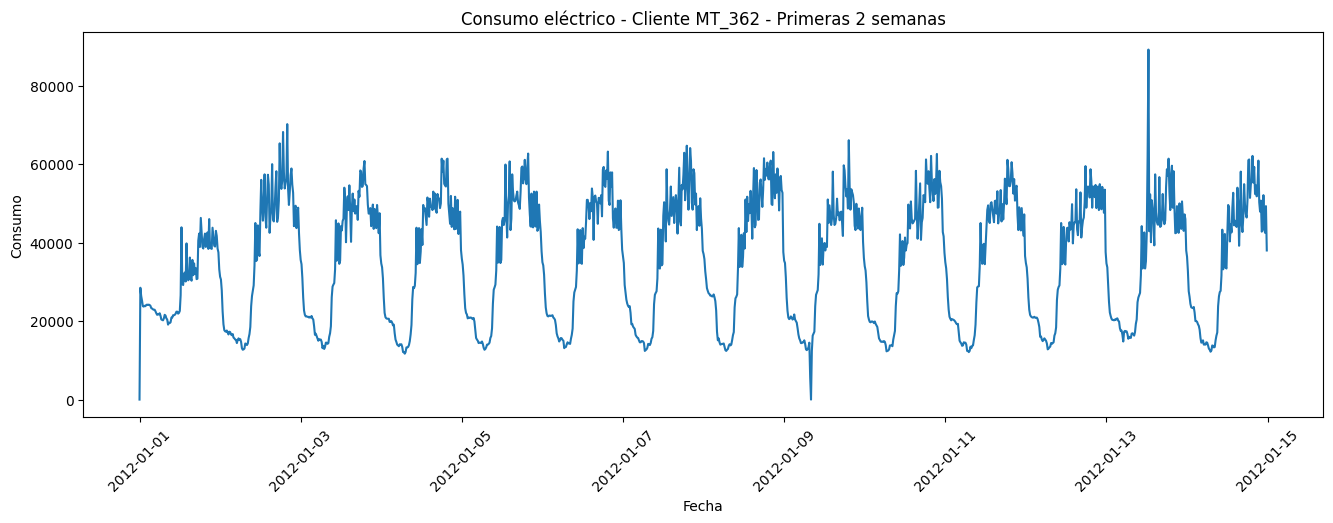

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

plt.plot(
    series_df["date"].iloc[:96*14],
    series_df["target"].iloc[:96*14]
)

plt.title(f"Consumo eléctrico - Cliente {target_col} - Primeras 2 semanas")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.show()

# 9. Guardar los datos en formato compatible con ETSformer

La implementación oficial de ETSformer espera un archivo CSV con:

- una columna `date`,
- una o más columnas numéricas.

Para este primer experimento, guardaremos:

| date | target |
|---|---:|

Dentro de la carpeta del repositorio ETSformer.

In [0]:
import os

data_dir = f"{repo_dir}/dataset/electricity_custom"
os.makedirs(data_dir, exist_ok=True)

custom_csv_path = f"{data_dir}/electricity_single.csv"

series_df.to_csv(custom_csv_path, index=False)

print("Archivo creado:", custom_csv_path)
display(pd.read_csv(custom_csv_path).head())

Archivo creado: /tmp/ETSformer/dataset/electricity_custom/electricity_single.csv


date,target
2012-01-01 00:00:00,0.0
2012-01-01 00:15:00,28500.0
2012-01-01 00:30:00,26400.0
2012-01-01 00:45:00,25200.0
2012-01-01 01:00:00,23800.0


%md
# 10. Entrenar ETSformer

Ahora entrenaremos el modelo.

Usaremos:

| Parámetro | Valor | Explicación |
|---|---:|---|
| `seq_len` | 96 | mira las últimas 24 horas |
| `pred_len` | 24 | predice las próximas 6 horas |
| `features` | S | usa una sola variable |
| `target` | target | columna a predecir |
| `enc_in` | 1 | una variable de entrada |
| `dec_in` | 1 | una variable del decoder |
| `c_out` | 1 | una variable de salida |
| `K` | 3 | número de frecuencias principales |
| `d_model` | 128 | tamaño interno del modelo |

ETSformer aprenderá:

\[
X_{t-96:t} \rightarrow X_{t:t+24}
\]

In [0]:
file_path = "/tmp/ETSformer/utils/tools.py"

with open(file_path, "r") as f:
    content = f.read()

content = content.replace("np.Inf", "np.inf")

with open(file_path, "w") as f:
    f.write(content)

print("Archivo corregido:", file_path)

Archivo corregido: /tmp/ETSformer/utils/tools.py


In [0]:
import subprocess

repo_dir = "/tmp/ETSformer"

cmd = [
    "python", "run.py",
    "--model_id", "electricity_quick_test",
    "--model", "ETSformer",
    "--data", "custom",
    "--root_path", "./dataset/electricity_custom/",
    "--data_path", "electricity_single.csv",
    "--features", "S",
    "--target", "target",
    "--freq", "15min",
    "--seq_len", "48",
    "--label_len", "0",
    "--pred_len", "12",
    "--enc_in", "1",
    "--dec_in", "1",
    "--c_out", "1",
    "--d_model", "32",
    "--n_heads", "2",
    "--e_layers", "1",
    "--d_layers", "1",
    "--d_ff", "64",
    "--K", "1",
    "--dropout", "0.2",
    "--learning_rate", "0.0001",
    "--batch_size", "16",
    "--train_epochs", "1",
    "--patience", "1",
    "--num_workers", "0",
    "--itr", "1"
]

process = subprocess.Popen(
    cmd,
    cwd=repo_dir,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in process.stdout:
    print(line, end="")

process.wait()

print("\nProceso terminado.")
print("Exit code:", process.returncode)

Args in experiment:
Namespace(model_id='electricity_quick_test', model='ETSformer', data='custom', root_path='./dataset/electricity_custom/', data_path='electricity_single.csv', features='S', target='target', freq='15min', checkpoints='./checkpoints/', seq_len=48, label_len=0, pred_len=12, enc_in=1, dec_in=1, c_out=1, d_model=32, n_heads=2, e_layers=1, d_layers=1, d_ff=64, K=1, dropout=0.2, embed='timeF', activation='sigmoid', min_lr=1e-30, warmup_epochs=3, std=0.2, smoothing_learning_rate=0, damping_learning_rate=0, output_attention=False, optim='adam', num_workers=0, itr=1, train_epochs=1, batch_size=16, patience=1, learning_rate=0.0001, des='test', lradj='exponential_with_warmup', use_gpu=False, gpu=0, use_multi_gpu=False, devices='0,1,2,3')
Use CPU
>>>>>>>start training : electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 73592
val 10512
test 21032
	iters: 100, epoch: 1 | loss: 0.9740393
	speed: 0.0284s/ite

%md
# 11. Qué está haciendo ETSformer

ETSformer combina ideas clásicas de series temporales con Transformers modernos.

## 11.1 Exponential Smoothing Attention

Da más importancia a observaciones recientes.

Esto sigue la lógica:

\[
peso_j = \alpha(1-\alpha)^j
\]

Interpretación:

| Observación pasada | Peso esperado |
|---|---:|
| hace 15 minutos | alto |
| hace 1 hora | alto/medio |
| hace 1 día | medio |
| hace mucho tiempo | bajo |

Esto es útil porque en consumo eléctrico el pasado reciente suele ser muy relevante.

## 11.2 Frequency Attention

ETSformer usa Fourier para encontrar ciclos dominantes.

En este caso puede detectar patrones como:

- ciclo diario,
- ciclo semanal,
- horarios pico,
- horarios valle.

El parámetro `K=3` indica que el modelo buscará tres frecuencias dominantes.

## 11.3 Descomposición

El modelo intenta construir la predicción como suma de:

\[
Forecast = Level + Growth + Seasonality
\]

Esto permite que el modelo no solo prediga, sino que internamente separe patrones temporales.

# 12. Buscar archivos de resultados

Después del entrenamiento, ETSformer guarda resultados dentro de:

- `results/`
- `checkpoints/`

Ahí encontraremos métricas, valores reales y predicciones.

In [0]:
import glob
import os

result_dirs = glob.glob(f"{repo_dir}/results/*")
checkpoint_dirs = glob.glob(f"{repo_dir}/checkpoints/*")

print("Carpetas de resultados:")
for p in result_dirs[-10:]:
    print(p)

print("\nCarpetas de checkpoints:")
for p in checkpoint_dirs[-10:]:
    print(p)

Carpetas de resultados:
/tmp/ETSformer/results/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0

Carpetas de checkpoints:
/tmp/ETSformer/checkpoints/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0


%md
# 13. Leer métricas de evaluación

Las métricas nos dicen qué tan lejos está la predicción del valor real.

Las más importantes son:

## MSE

\[
MSE = \frac{1}{N}\sum(y-\hat{y})^2
\]

Penaliza más los errores grandes.

## MAE

\[
MAE = \frac{1}{N}\sum |y-\hat{y}|
\]

Representa el error promedio absoluto.

Valores más bajos son mejores.

In [0]:
import numpy as np

metric_files = glob.glob(f"{repo_dir}/results/**/metrics.npy", recursive=True)

print("Archivos metrics encontrados:", len(metric_files))

for mf in metric_files[-5:]:
    metrics = np.load(mf)
    print("\nArchivo:", mf)
    print("Métricas:", metrics)

Archivos metrics encontrados: 0


# 14. Cargar predicciones

ETSformer suele guardar dos archivos principales:

- `pred.npy`: predicciones del modelo.
- `true.npy`: valores reales.

Cada predicción tiene 24 pasos futuros.

Como cada paso equivale a 15 minutos:

\[
24 \times 15 = 360 \text{ minutos}
\]

Es decir, cada predicción cubre las próximas 6 horas.


In [0]:
import glob
import numpy as np
import matplotlib.pyplot as plt

repo_dir = "/tmp/ETSformer"

pred_files = glob.glob(f"{repo_dir}/results/**/pred.npy", recursive=True)
true_files = glob.glob(f"{repo_dir}/results/**/true.npy", recursive=True)

print("pred.npy encontrados:", len(pred_files))
print("true.npy encontrados:", len(true_files))

print(pred_files)
print(true_files)

if len(pred_files) == 0 or len(true_files) == 0:
    raise FileNotFoundError("No se encontraron pred.npy o true.npy en /tmp/ETSformer/results")

pred = np.load(pred_files[-1])
true = np.load(true_files[-1])

print("Forma pred:", pred.shape)
print("Forma true:", true.shape)

pred.npy encontrados: 0
true.npy encontrados: 0
[]
[]


---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
File <command-7973370936110792>, line 17
     14 print(true_files)
     16 if len(pred_files) == 0 or len(true_files) == 0:
---> 17     raise FileNotFoundError("No se encontraron pred.npy o true.npy en /tmp/ETSformer/results")
     19 pred = np.load(pred_files[-1])
     20 true = np.load(true_files[-1])

FileNotFoundError: No se encontraron pred.npy o true.npy en /tmp/ETSformer/results

In [0]:
import shutil
import os

checkpoint_dir = "/tmp/ETSformer/checkpoints"

if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)

os.makedirs(checkpoint_dir, exist_ok=True)

print("Checkpoints eliminados.")

Checkpoints eliminados.


In [0]:
import glob
import numpy as np
import matplotlib.pyplot as plt

repo_dir = "/tmp/ETSformer"

pred_files = glob.glob(f"{repo_dir}/results/**/pred.npy", recursive=True)
true

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5512996080305713>, line 8
      5 repo_dir = "/tmp/ETSformer"
      7 pred_files = glob.glob(f"{repo_dir}/results/**/pred.npy", recursive=True)
----> 8 true

NameError: name 'true' is not defined

In [0]:
import glob

checkpoint_files = glob.glob("/tmp/ETSformer/checkpoints/**/*.pth", recursive=True)

print("Checkpoints encontrados:", len(checkpoint_files))

for c in checkpoint_files:
    print(c)

Checkpoints encontrados: 1
/tmp/ETSformer/checkpoints/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0/checkpoint.pth


In [0]:
metric_files = glob.glob("/tmp/ETSformer/results/**/metrics.npy", recursive=True)

print(metric_files)

[]


In [0]:
%sh
grep -n "def test" -A 120 /tmp/ETSformer/exp/exp_main.py

182:    def test(self, setting, data, save_vals=False):
183-        """data - 'val' or 'test' """
184-        test_data, test_loader = self._get_data(flag=data)
185-
186-        print('loading model')
187-        self.model.load_state_dict(torch.load(os.path.join('./checkpoints/' + setting, 'checkpoint.pth')))
188-
189-        preds = []
190-        trues = []
191-
192-        self.model.eval()
193-        with torch.no_grad():
194-            for i, (batch_x, batch_y, batch_x_mark, batch_y_mark) in enumerate(test_loader):
195-                batch_x = batch_x.float().to(self.device)
196-                batch_y = batch_y.float().to(self.device)
197-
198-                batch_x_mark = batch_x_mark.float().to(self.device)
199-                batch_y_mark = batch_y_mark.float().to(self.device)
200-
201-                # decoder input
202-                dec_inp = torch.zeros_like(batch_y[:, -self.args.pred_len:, :]).float()
203-                dec_inp = torch.cat([batch_y[:, :self.args.la

In [0]:
import sys
import os
import glob
from argparse import Namespace

repo_dir = "/tmp/ETSformer"
os.chdir(repo_dir)
sys.path.append(repo_dir)

from exp.exp_main import Exp_Main

checkpoint_dirs = glob.glob(f"{repo_dir}/checkpoints/*")

print("Checkpoints encontrados:")
for c in checkpoint_dirs:
    print(c)

setting = os.path.basename(checkpoint_dirs[-1])
print("\nUsando setting:", setting)

args = Namespace(
    model_id="electricity_quick_test",
    model="ETSformer",
    data="custom",
    root_path="./dataset/electricity_custom/",
    data_path="electricity_single.csv",
    features="S",
    target="target",
    freq="15min",
    checkpoints="./checkpoints/",
    seq_len=48,
    label_len=0,
    pred_len=12,
    enc_in=1,
    dec_in=1,
    c_out=1,
    d_model=32,
    n_heads=2,
    e_layers=1,
    d_layers=1,
    d_ff=64,
    K=1,
    dropout=0.2,
    embed="timeF",
    activation="sigmoid",
    min_lr=1e-30,
    warmup_epochs=3,
    std=0.2,
    smoothing_learning_rate=0,
    damping_learning_rate=0,
    output_attention=False,
    optim="adam",
    num_workers=0,
    itr=1,
    train_epochs=1,
    batch_size=16,
    patience=1,
    learning_rate=0.0001,
    des="test",
    lradj="exponential_with_warmup",
    use_gpu=False,
    gpu=0,
    use_multi_gpu=False,
    devices="0,1,2,3"
)

exp = Exp_Main(args)
exp.test(setting, data="test", save_vals=True)

print("Predicciones guardadas.")

Checkpoints encontrados:
/tmp/ETSformer/checkpoints/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0

Usando setting: electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0
Use CPU
test 21032
loading model
test shape: (1314, 16, 12, 1) (1314, 16, 12, 1)
test shape: (21024, 12, 1) (21024, 12, 1)
mse:0.6291270852088928, mae:0.6090076565742493
Predicciones guardadas.


In [0]:
import glob

pred_files = glob.glob("/tmp/ETSformer/results/**/pred.npy", recursive=True)
true_files = glob.glob("/tmp/ETSformer/results/**/true.npy", recursive=True)

print(pred_files)
print(true_files)

['/tmp/ETSformer/results/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0/pred.npy']
['/tmp/ETSformer/results/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0/true.npy']


In [0]:
import numpy as np
import matplotlib.pyplot as plt

pred_path = "/tmp/ETSformer/results/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0/pred.npy"

true_path = "/tmp/ETSformer/results/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0/true.npy"

pred = np.load(pred_path)
true = np.load(true_path)

print("pred shape:", pred.shape)
print("true shape:", true.shape)

example_id = 0

y_true = true[example_id, :, 0]
y_pred = pred[example_id, :, 0]

plt.figure(figsize=(12,5))

plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Predicción")

plt.title("ETSformer Forecast")
plt.xlabel("Pasos futuros (15 min)")
plt.ylabel("Consumo")

plt.legend()
plt.show()

pred shape: (21024, 12, 1)
true shape: (21024, 12, 1)


In [0]:
import matplotlib.pyplot as plt

example_id = 0

y_true = true[example_id, :, 0]
y_pred = pred[example_id, :, 0]

plt.figure(figsize=(12,5))

plt.plot(y_true, marker='o', label="Real")
plt.plot(y_pred, marker='x', label="Predicción")

plt.title("ETSformer Forecast")
plt.xlabel("Horizonte futuro (15 min)")
plt.ylabel("Consumo")

plt.legend()
plt.grid(True)

plt.show()

In [0]:
import numpy as np
import matplotlib.pyplot as plt

pred_path = "/tmp/ETSformer/results/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0/pred.npy"
true_path = "/tmp/ETSformer/results/electricity_quick_test_ETSformer_custom_ftS_sl48_pl12_dm32_nh2_el1_dl1_df64_K1_lr0.0001_test_0/true.npy"

pred = np.load(pred_path)
true = np.load(true_path)

example_id = 0

y_true = true[example_id, :, 0]
y_pred = pred[example_id, :, 0]

print("Real:", y_true)
print("Predicción:", y_pred)

plt.figure(figsize=(12, 5))
plt.plot(y_true, marker="o", label="Real")
plt.plot(y_pred, marker="x", label="Predicción")
plt.title("ETSformer Forecast")
plt.xlabel("Horizonte futuro: pasos de 15 minutos")
plt.ylabel("Consumo")
plt.legend()
plt.grid(True)
plt.show()

Real: [ 0.52329683 -0.06856176  0.05904078  0.17578353  0.17035364  0.06447067
  0.40655407  0.2762366   0.27895153  0.0889052   0.24637216  0.09433509]
Predicción: [0.21313424 0.22944632 0.14112371 0.12793499 0.13860911 0.05721754
 0.07882461 0.08474457 0.02711615 0.08507526 0.08974072 0.06792066]
